# 02 · EDA
**Proyecto Integrador – Data Mining Tools (CC209)** · TP1

Cubre el **Paso 3** (auditoría inicial) y el **Paso 4** (EDA guiado por preguntas).
En cada resultado se separa **lo que muestran los datos** de **lo que interpretamos**.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_FILE = ROOT / "data" / "raw" / "kc_house_data.csv"
FIG = ROOT / "reports" / "figures"
TAB = ROOT / "reports" / "tables"
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)


def guardar_fig(nombre):
    plt.savefig(FIG / f"{nombre}.png", dpi=150, bbox_inches="tight")

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

## 3. Carga y auditoría inicial
Se trabaja sobre una copia en memoria: el archivo de `data/raw/` no se modifica.

In [2]:
df = pd.read_csv(RAW_FILE)
print(f"Forma: {df.shape}")
df.head()

Forma: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
df.describe().T[["min", "25%", "50%", "75%", "max"]]

,min,25%,50%,75%,max
id,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


**Qué muestran los datos**
- `bedrooms` va de 0 a **33**, y `bathrooms` llega a 0: hay valores que parecen errores o casos especiales.
- `price` va de 75 mil a 7.7 millones, con una mediana de 450 mil: rango muy amplio.
- `sqft_lot` llega a 1.65 millones de pies² frente a una mediana de ~7 600: cola extrema.
- `yr_renovated` y `sqft_basement` tienen mediana 0 (ceros que significan "no aplica").

**Interpretación (hipótesis a verificar en los Pasos 4 y 5)**
- Las variables de tamaño y precio probablemente son muy asimétricas y requerirán transformación logarítmica.
- Los valores de 0 dormitorios/baños y los 33 dormitorios deben revisarse contra otras variables (por ejemplo `sqft_living`) antes de decidir si son errores.

### 3.1 Fecha de venta
`date` viene como texto (`YYYYMMDDT000000`). Se convierte a fecha **en la copia de trabajo**.

In [4]:
df["fecha"] = pd.to_datetime(df["date"], format="%Y%m%dT%H%M%S")
df["anio_venta"] = df["fecha"].dt.year
df["mes_venta"] = df["fecha"].dt.month

print("Rango:", df["fecha"].min().date(), "->", df["fecha"].max().date())
ventas_mes = df.groupby(df["fecha"].dt.to_period("M")).size().rename("ventas")
ventas_mes.to_frame()

Rango: 2014-05-02 -> 2015-05-27


,ventas
fecha,
2014-05,1768
2014-06,2180
2014-07,2211
2014-08,1940
2014-09,1774
2014-10,1878
2014-11,1411
2014-12,1471
2015-01,978


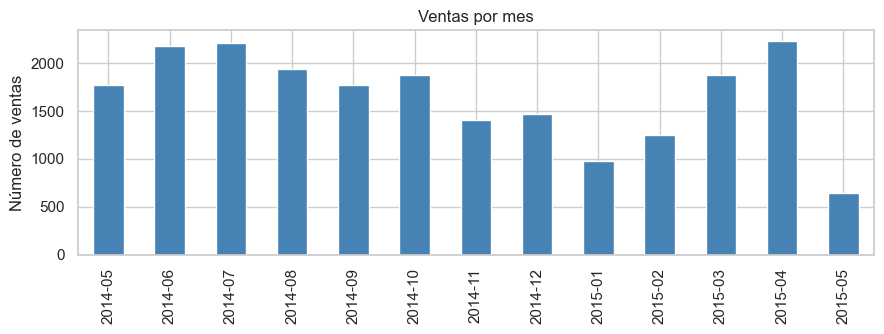

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ventas_mes.plot.bar(ax=ax, color="steelblue")
ax.set_title("Ventas por mes")
ax.set_xlabel("")
ax.set_ylabel("Número de ventas")
plt.tight_layout()
guardar_fig("eda_01_ventas_por_mes")
plt.show()

**Qué muestran los datos**
- Hay entre ~1 000 y ~2 200 ventas por mes, con menos actividad en invierno (dic–feb).
- Mayo de 2015 tiene solo 646 ventas porque el registro termina el día 27, y mayo de 2014 empieza el día 2.

**Interpretación**
- La caída de mayo de 2015 es un efecto del corte del dataset, no del mercado.
- Con solo ~13 meses no se puede separar estacionalidad de tendencia: cualquier efecto de "mes" queda confundido con el año.

### 3.2 Unicidad de `id`: ventas repetidas

In [6]:
repetidos = df[df["id"].duplicated(keep=False)].sort_values(["id", "fecha"])

print(f"Filas totales:                   {len(df):,}")
print(f"id únicos:                       {df['id'].nunique():,}")
print(f"Viviendas vendidas más de 1 vez: {repetidos['id'].nunique():,} ({len(repetidos)} filas)")
print(f"Máximo de ventas por vivienda:   {repetidos.groupby('id').size().max()}")
print(f"Filas duplicadas exactas:        {df.drop(columns=['fecha', 'anio_venta', 'mes_venta']).duplicated().sum()}")
print(f"Mismo id y misma fecha:          {repetidos.duplicated(['id', 'fecha']).sum()}")

Filas totales:                   21,613
id únicos:                       21,436
Viviendas vendidas más de 1 vez: 176 (353 filas)
Máximo de ventas por vivienda:   3
Filas duplicadas exactas:        0
Mismo id y misma fecha:          0


In [7]:
cambio = repetidos.groupby("id")["price"].agg(primera="first", ultima="last")
cambio["variacion_%"] = (cambio["ultima"] / cambio["primera"] - 1) * 100
cambio["variacion_%"].describe().round(1).to_frame("variación de precio entre ventas (%)")

,variación de precio entre ventas (%)
count,176.0
mean,56.8
std,46.7
min,-5.4
25%,23.6
50%,54.4
75%,74.2
max,321.8


**Qué muestran los datos**
- **176 viviendas** aparecen más de una vez (353 filas, máximo 3 ventas). No hay filas duplicadas exactas ni dos ventas con el mismo `id` y la misma fecha.
- Entre la primera y la última venta, el precio sube una **mediana de ~54 %** (rango de −5 % a +322 %) en pocos meses.

**Interpretación**
- No son duplicados que haya que eliminar: son **ventas distintas** de la misma propiedad. Eliminarlas sería perder información.
- Una subida tan grande en menos de un año sugiere reventas con mejoras o compras para revender (*flipping*). Eso es relevante para la detección de anomalías, y es una hipótesis: el dataset no lo confirma.
- **Consecuencia para el split (Paso 6):** si una misma vivienda queda en train y en test, el modelo se evalúa con propiedades que ya vio. Hay que agrupar por `id`.

---
## 4. EDA guiado por preguntas
Cada bloque parte de una pregunta cuya respuesta condiciona una decisión posterior.

### 4.1 ¿Cómo se distribuye el precio y conviene transformarlo?
*Decisión que condiciona:* si el modelo predice `price` o `log(price)`.

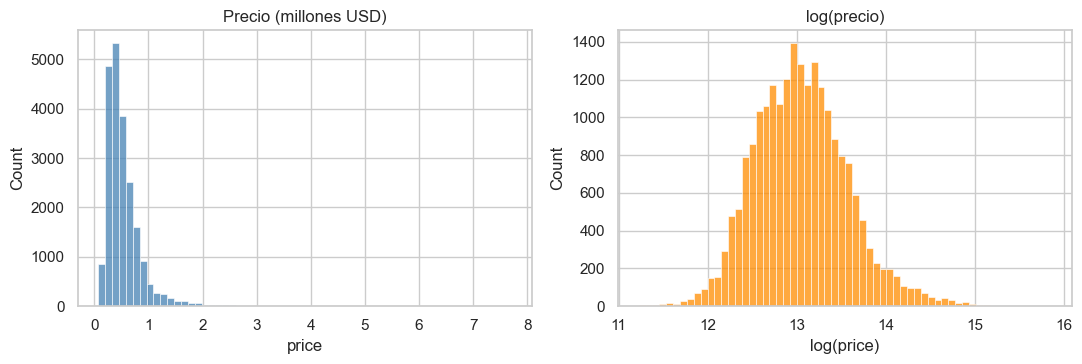

Asimetría de price:       4.02
Asimetría de log(price):  0.43
Percentiles 1/50/90/99:   [153500.0, 450000.0, 887000.0, 1964400.0]


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.histplot(df["price"] / 1e6, bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Precio (millones USD)")
axes[0].set_xlabel("price")
sns.histplot(np.log(df["price"]), bins=60, ax=axes[1], color="darkorange")
axes[1].set_title("log(precio)")
axes[1].set_xlabel("log(price)")
plt.tight_layout()
guardar_fig("eda_02_distribucion_precio")
plt.show()

print("Asimetría de price:      ", round(df["price"].skew(), 2))
print("Asimetría de log(price): ", round(np.log(df["price"]).skew(), 2))
print("Percentiles 1/50/90/99:  ", df["price"].quantile([.01, .5, .9, .99]).round(0).tolist())

**Qué muestran los datos**
- `price` tiene asimetría **4.0**: la mayoría de las ventas se concentra bajo ~900 mil y hay una cola larga hasta 7.7 millones.
- Con `log(price)` la asimetría baja a **0.43** y la distribución queda casi simétrica.

**Interpretación**
- Un modelo entrenado sobre `price` crudo daría mucho peso a unas pocas ventas millonarias.
- **Decisión provisional:** modelar `log(price)` y reportar las métricas también en dólares. Se confirma al comparar modelos.

### 4.2 ¿Cómo se relaciona el tamaño con el precio?

In [9]:
asim = pd.DataFrame({
    "asimetría": df[["sqft_living", "sqft_lot", "sqft_above", "sqft_basement"]].skew(),
    "asimetría tras log1p": np.log1p(df[["sqft_living", "sqft_lot", "sqft_above", "sqft_basement"]]).skew(),
}).round(2)
asim

,asimetría,asimetría tras log1p
sqft_living,1.47,-0.03
sqft_lot,13.06,0.96
sqft_above,1.45,0.25
sqft_basement,1.58,0.48


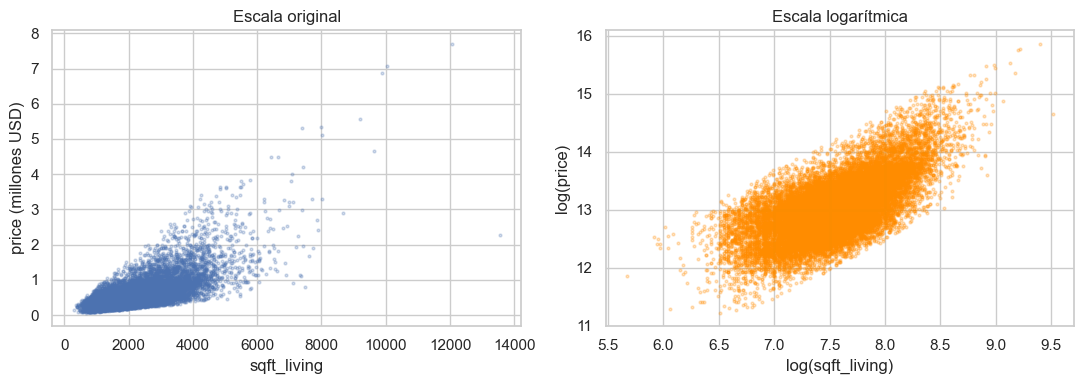

,median,mean,std
sqft_living,,,
Q1,320000.0,339015.0,133678.0
Q2,400000.0,421805.0,160779.0
Q3,490000.0,521474.0,206291.0
Q4,756000.0,881266.0,533540.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(df["sqft_living"], df["price"] / 1e6, s=4, alpha=.25)
axes[0].set_xlabel("sqft_living")
axes[0].set_ylabel("price (millones USD)")
axes[0].set_title("Escala original")
axes[1].scatter(np.log(df["sqft_living"]), np.log(df["price"]), s=4, alpha=.25, color="darkorange")
axes[1].set_xlabel("log(sqft_living)")
axes[1].set_ylabel("log(price)")
axes[1].set_title("Escala logarítmica")
plt.tight_layout()
guardar_fig("eda_03_tamano_vs_precio")
plt.show()

cuartil = pd.qcut(df["sqft_living"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
df.groupby(cuartil, observed=True)["price"].agg(["median", "mean", "std"]).round(0)

**Qué muestran los datos**
- La superficie habitable (`sqft_living`) tiene asimetría 1.5 y `sqft_lot` **13.1**; tras `log1p` bajan a ~0 y 0.96.
- El precio sube con el tamaño, y la **dispersión en dólares también crece** con el tamaño (columna `std` por cuartil).
- En escala logarítmica la relación se ve más lineal y la dispersión más pareja.

**Interpretación**
- `sqft_lot` está dominada por unos pocos terrenos enormes: conviene transformarla con `log1p`.
- La dispersión creciente en la escala original es otra razón para modelar `log(price)`: un error de 100 mil significa cosas muy distintas en una casa de 300 mil y en una de 2 millones.

### 4.3 ¿Pesan más la calidad y las características del inmueble o la ubicación?

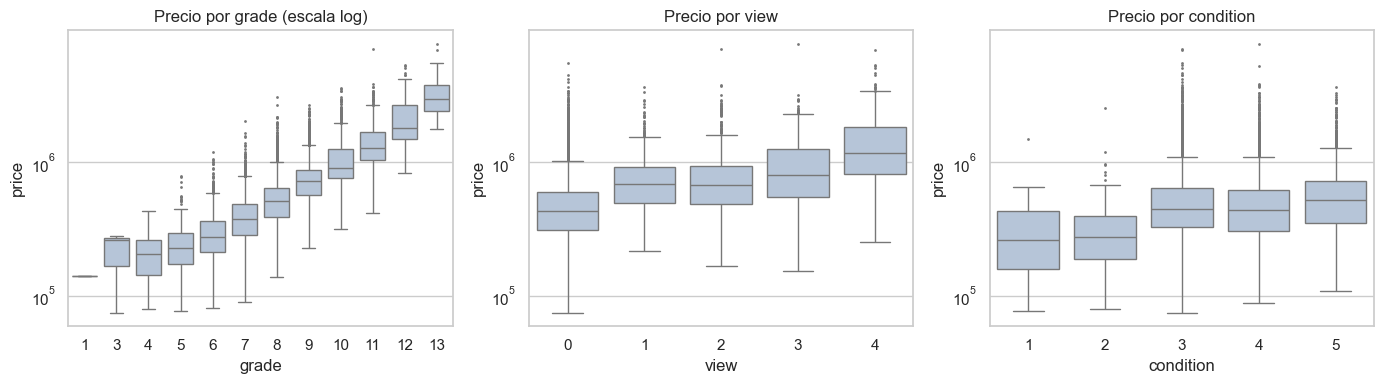

,size,median
waterfront,,
0,21450,450000.0
1,163,1400000.0


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(data=df, x="grade", y="price", ax=axes[0], color="lightsteelblue", fliersize=1)
axes[0].set_yscale("log"); axes[0].set_title("Precio por grade (escala log)")
sns.boxplot(data=df, x="view", y="price", ax=axes[1], color="lightsteelblue", fliersize=1)
axes[1].set_yscale("log"); axes[1].set_title("Precio por view")
sns.boxplot(data=df, x="condition", y="price", ax=axes[2], color="lightsteelblue", fliersize=1)
axes[2].set_yscale("log"); axes[2].set_title("Precio por condition")
plt.tight_layout()
guardar_fig("eda_04_grade_view_condition")
plt.show()

df.groupby("waterfront")["price"].agg(["size", "median"])

**Qué muestran los datos**
- **`grade`:** la mediana pasa de ~275 mil (grade 6) a ~1.3 millones (grade 11) y ~3.0 millones (grade 13). Es una relación creciente y marcada. Los grados extremos tienen muy pocas casas (grade 1: 1 vivienda; grade 13: 13).
- **`view` y `waterfront`:** sin vista (`view = 0`) la mediana es ~433 mil y con la mejor vista (`view = 4`) ~1.19 millones. Las **163** viviendas frente al agua tienen mediana de 1.4 millones, contra 450 mil las demás.
- **`condition`:** casi no separa precios entre 3, 4 y 5 (450 mil, 440 mil y 526 mil), y el 65 % de las casas tiene condición 3.

**Interpretación**
- `grade`, `view` y `waterfront` parecen buenos predictores. Que `waterfront` afecte tanto el precio con tan pocos casos indica que el modelo tendrá poca evidencia para esa categoría.
- `condition` aporta poco por sí sola. Probablemente su efecto esté absorbido por `grade` y por el año de construcción (hipótesis, no verificada).

### 4.4 ¿Cómo influye la ubicación?

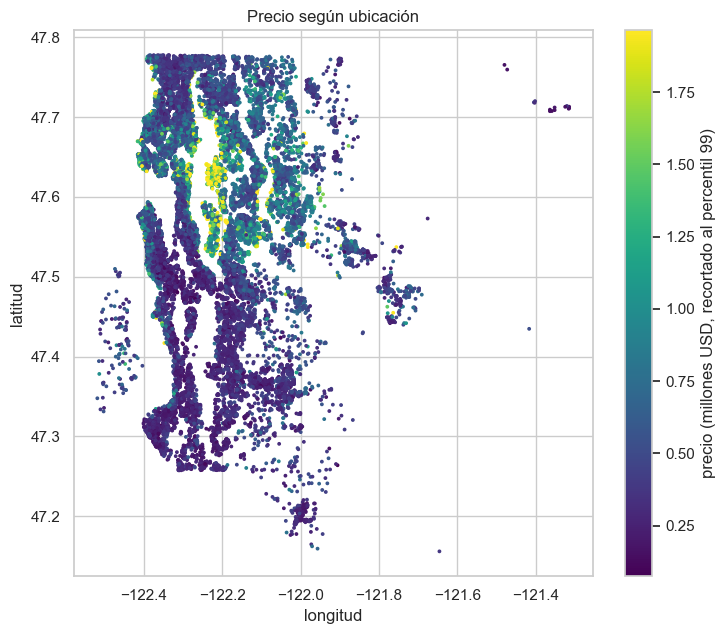

In [12]:
tope = df["price"].quantile(.99)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
sc = ax.scatter(df["long"], df["lat"], c=df["price"].clip(upper=tope) / 1e6, s=3, cmap="viridis")
plt.colorbar(sc, ax=ax, label="precio (millones USD, recortado al percentil 99)")
ax.set_xlabel("longitud"); ax.set_ylabel("latitud")
ax.set_title("Precio según ubicación")
plt.tight_layout()
guardar_fig("eda_05_mapa_precio")
plt.show()

In [13]:
por_zip = (df.groupby("zipcode")["price"].agg(ventas="size", mediana="median")
             .sort_values("mediana"))
print("Códigos postales:", len(por_zip))
pd.concat([por_zip.head(5), por_zip.tail(5)])

Códigos postales: 70


,ventas,mediana
zipcode,,
98002,199,235000.0
98168,269,235000.0
98032,125,249000.0
98001,362,260000.0
98188,136,264000.0
98005,168,765475.0
98112,269,915000.0
98040,282,993750.0
98004,317,1150000.0


**Qué muestran los datos**
- Hay **70 códigos postales**. La mediana va de **235 mil** (98002 y 98168) a **1.89 millones** (98039, con solo 50 ventas); 98004 también supera el millón y 98040 se acerca (~994 mil).
- El mapa muestra que los precios altos se concentran en zonas concretas, no repartidos al azar.
- La latitud tiene correlación de Spearman con el precio de **0.46**, cercana a la de `bathrooms` (0.50) y mayor que la de `bedrooms` (0.34) o `floors` (0.32).

**Interpretación**
- La ubicación es un determinante fuerte: la diferencia entre el código postal más barato y el más caro es de ~8 veces en la mediana.
- `zipcode` es una **categoría**, no una cantidad: no sirve usar su valor numérico, y con 70 niveles hay que decidir cómo codificarlo (Paso 7). `lat` y `long` ofrecen una alternativa continua, y agrupar zonas (clustering) es una vía para el TF1.

### 4.5 ¿Importan la antigüedad y las renovaciones?

In [14]:
df["decada_construccion"] = (df["yr_built"] // 20) * 20
renov = (df["yr_renovated"] > 0).rename("renovada")

print(f"Viviendas renovadas: {renov.mean():.1%} | con sótano: {(df['sqft_basement'] > 0).mean():.1%}")
display(df.groupby("decada_construccion")["price"].agg(ventas="size", mediana="median"))
display(df.groupby(renov)["price"].agg(ventas="size", mediana="median"))

Viviendas renovadas: 4.2% | con sótano: 39.3%


,ventas,mediana
decada_construccion,,
1900,1451,532500.0
1920,1722,525000.0
1940,4216,396000.0
1960,4945,405000.0
1980,4520,470000.0
2000,4759,503045.0


,ventas,mediana
renovada,,
False,20699,448000.0
True,914,600000.0


**Qué muestran los datos**
- Solo el **4.2 %** de las viviendas figura como renovada; el **39 %** tiene sótano.
- La mediana por período de construcción **no es monótona**: las casas de 1900–1939 (~530 mil) cuestan más que las de 1940–1979 (~400 mil), y las nuevas vuelven a subir (~500 mil).
- Las renovadas tienen mediana de 600 mil frente a 448 mil de las no renovadas.

**Interpretación**
- La antigüedad por sí sola no ordena el precio: las casas antiguas y las nuevas valen más que las de mitad de siglo. Un modelo lineal en `yr_built` lo captaría mal; los modelos de árboles sí pueden.
- La diferencia entre renovadas y no renovadas no es un efecto causal: las renovadas son pocas y pueden estar en zonas más caras. No se concluye que renovar suba el precio.
- Conviene derivar variables claras: `renovada` (0/1), `tiene_sotano` y antigüedad al momento de la venta.

### 4.6 ¿Qué variables se relacionan entre sí? (multicolinealidad)
`zipcode`, `id` y `date` se excluyen: no son cantidades.

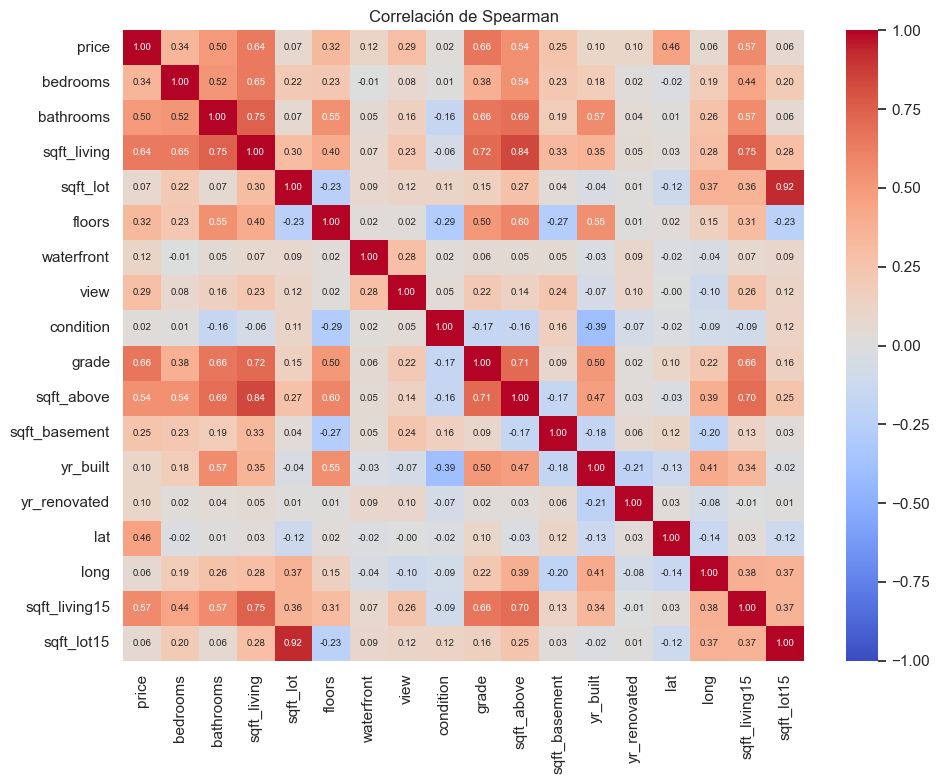

,Spearman con price
grade,0.66
sqft_living,0.64
sqft_living15,0.57
sqft_above,0.54
bathrooms,0.50
lat,0.46
bedrooms,0.34
floors,0.32
view,0.29
sqft_basement,0.25


In [15]:
num = df.drop(columns=["id", "date", "fecha", "zipcode", "decada_construccion", "anio_venta", "mes_venta"])
corr = num.corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlación de Spearman")
plt.tight_layout()
guardar_fig("eda_06_correlaciones")
plt.show()

corr["price"].drop("price").sort_values(ascending=False).round(2).to_frame("Spearman con price")

In [16]:
print("sqft_above + sqft_basement == sqft_living en el",
      f"{((df['sqft_above'] + df['sqft_basement']) == df['sqft_living']).mean():.0%} de las filas")
corr.loc[["sqft_living", "sqft_above", "sqft_living15", "grade", "bathrooms"],
         ["sqft_living", "sqft_above", "sqft_living15", "grade", "bathrooms"]].round(2)

sqft_above + sqft_basement == sqft_living en el 100% de las filas


,sqft_living,sqft_above,sqft_living15,grade,bathrooms
sqft_living,1.00,0.84,0.75,0.72,0.75
sqft_above,0.84,1.00,0.70,0.71,0.69
sqft_living15,0.75,0.70,1.00,0.66,0.57
grade,0.72,0.71,0.66,1.00,0.66
bathrooms,0.75,0.69,0.57,0.66,1.00


**Qué muestran los datos**
- Mayor correlación con el precio: `grade` (0.66), `sqft_living` (0.64), `sqft_living15` (0.57), `sqft_above` (0.54), `bathrooms` (0.50), `lat` (0.46).
- `condition` (0.02), `sqft_lot` (0.07) y `yr_built` (0.10) casi no se asocian de forma monótona con el precio.
- `sqft_above + sqft_basement = sqft_living` en el **100 %** de las filas, y `sqft_living` está muy correlacionada con `sqft_above` (0.84), `bathrooms` (0.75) y `sqft_living15` (0.75).

**Interpretación**
- Hay **redundancia exacta**: `sqft_living` es la suma de otras dos columnas. Para modelos lineales conviene conservar solo algunas; los árboles toleran mejor la redundancia.
- Spearman mide asociación monótona: una correlación baja (como `yr_built`) no significa que no haya relación, y como vimos en 4.5, esa relación no es monótona.

### 4.7 ¿Qué casos extremos o sospechosos hay?

In [17]:
sospechosos = df[(df["bedrooms"] == 0) | (df["bathrooms"] == 0) | (df["bedrooms"] >= 10)]
print(f"bedrooms == 0: {(df['bedrooms'] == 0).sum()} | bathrooms == 0: {(df['bathrooms'] == 0).sum()} | "
      f"ambos 0: {((df['bedrooms'] == 0) & (df['bathrooms'] == 0)).sum()} | bedrooms >= 10: {(df['bedrooms'] >= 10).sum()}")
sospechosos[["id", "price", "bedrooms", "bathrooms", "sqft_living", "grade"]].sort_values("bedrooms", ascending=False)

bedrooms == 0: 13 | bathrooms == 0: 10 | ambos 0: 7 | bedrooms >= 10: 5


,id,price,bedrooms,bathrooms,sqft_living,grade
15870,2402100895,640000.0,33,1.75,1620,7
8757,1773100755,520000.0,11,3.00,3000,7
13314,627300145,1148000.0,10,5.25,4590,9
19254,8812401450,660000.0,10,3.00,2920,7
15161,5566100170,650000.0,10,2.00,3610,7
1149,3421079032,75000.0,1,0.00,670,3
5832,5702500050,280000.0,1,0.00,600,3
10481,203100435,484000.0,1,0.00,690,7
875,6306400140,1095000.0,0,0.00,3064,7
4868,6896300380,228000.0,0,1.00,390,4


In [18]:
df["precio_por_pie2"] = df["price"] / df["sqft_living"]
display(df["precio_por_pie2"].describe().round(0).to_frame("USD por pie²"))
df.nlargest(5, "price")[["price", "sqft_living", "grade", "waterfront", "zipcode"]]

,USD por pie²
count,21613.0
mean,264.0
std,110.0
min,88.0
25%,182.0
50%,245.0
75%,318.0
max,810.0


,price,sqft_living,grade,waterfront,zipcode
7252,7700000.0,12050,13,0,98102
3914,7062500.0,10040,11,1,98004
9254,6885000.0,9890,13,0,98039
4411,5570000.0,9200,13,0,98039
1448,5350000.0,8000,12,0,98004


**Qué muestran los datos**
- Hay **13** viviendas con 0 dormitorios y **10** con 0 baños (16 en total con alguno de los dos en 0); su mediana de superficie es ~1 450 pies², no la de un estudio.
- Una vivienda declara **33 dormitorios** con solo 1 620 pies² y 1.75 baños. Hay otras 4 con 10 o 11 dormitorios.
- El precio por pie² va de 88 a 810 USD, con mediana de 245.
- Las 5 ventas más caras (5.35 a 7.7 millones) son casas grandes (8 000 a 12 050 pies²) de grade alto (11 a 13), ubicadas en solo 3 códigos postales.

**Interpretación**
- Los 33 dormitorios en 1 620 pies² son casi con certeza un **error de digitación** (por ejemplo 3). Los 0 dormitorios/baños en casas de ~1 450 pies² parecen **datos faltantes codificados como 0**, no estudios. Ambos son hipótesis: se decide en el Paso 5.
- Las ventas más caras no parecen errores: son coherentes con tamaño, calidad y ubicación. Son valores extremos **legítimos** y deben conservarse.

### 4.8 Hallazgos que condicionan la preparación

| # | Hallazgo | Evidencia | Decisión para el Paso 5 / 6 / 7 |
|---|---|---|---|
| 1 | `price` muy asimétrico | asimetría 4.0 → 0.43 con log | Modelar `log(price)`; reportar métricas también en USD |
| 2 | `sqft_lot` con cola extrema | asimetría 13.1 → 0.96 con `log1p` | Aplicar `log1p` a las superficies |
| 3 | Dispersión del precio crece con el tamaño | tabla por cuartiles de `sqft_living` | Reforzar el uso de la escala log; evaluar con error relativo |
| 4 | La ubicación pesa mucho | mediana de 235 mil a 1.89 millones por código postal | Tratar `zipcode` como categoría; evaluar usar `lat`/`long`; clustering en el TF1 |
| 5 | `yr_built` no monótona | medianas por período | Derivar antigüedad; usar modelos que capturen no linealidad |
| 6 | Redundancia exacta en superficies | `sqft_above + sqft_basement = sqft_living` (100 %) | Elegir variables con cuidado en modelos lineales |
| 7 | Ceros que significan "no aplica" | `yr_renovated`, `sqft_basement` | Crear indicadores `renovada` y `tiene_sotano` |
| 8 | 0 dormitorios/baños y 33 dormitorios | 16 + 1 casos, con superficies normales | Revisar y decidir si se corrigen, se tratan como faltantes o se descartan |
| 9 | Ventas repetidas de una misma vivienda | 176 `id`, mediana +54 % entre ventas | Agrupar por `id` en el split; tratar con cautela en anomalías |
| 10 | Categorías con pocos casos | `waterfront` 163, `grade` 1 y 13 | Cuidado con el sobreajuste y con la evaluación en esos grupos |

### 4.9 Tablas guardadas para el informe
Se guardan en `reports/tables/` (CSV) junto a las figuras de `reports/figures/`.

In [19]:
ventas_mes.rename("ventas").to_frame().to_csv(TAB / "eda_ventas_por_mes.csv")
corr.round(3).to_csv(TAB / "eda_correlacion_spearman.csv")
por_zip.to_csv(TAB / "eda_precio_por_zipcode.csv")
(df.groupby("grade")["price"].agg(ventas="size", mediana="median").round(0)
   .to_csv(TAB / "eda_precio_por_grade.csv"))
(df.groupby(cuartil, observed=True)["price"].agg(["median", "mean", "std"]).round(0)
   .to_csv(TAB / "eda_dispersion_por_cuartil_sqft.csv"))
print(sorted(p.name for p in TAB.glob("eda_*.csv")))
print(sorted(p.name for p in FIG.glob("eda_*.png")))

['eda_correlacion_spearman.csv', 'eda_dispersion_por_cuartil_sqft.csv', 'eda_precio_por_grade.csv', 'eda_precio_por_zipcode.csv', 'eda_ventas_por_mes.csv']
['eda_01_ventas_por_mes.png', 'eda_02_distribucion_precio.png', 'eda_03_tamano_vs_precio.png', 'eda_04_grade_view_condition.png', 'eda_05_mapa_precio.png', 'eda_06_correlaciones.png']
